# **Set up**

In [273]:
import matplotlib.ticker as ticker
%run ../../../setup_workspace.py # ../ means level up 

# **Function**

In [69]:
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

def polydisperse_lamellae(q, scale, L_c, p, bkg):

    sigma = p * L_c

    L_min = max(L_c - 3 * sigma, 0.00001)
    L_max = L_c + 3 * sigma
    L_values = np.linspace(L_min, L_max, 100)
    
    I_PD = np.zeros_like(q)
    
    for L in L_values:
        weight = gaussian(L, L_c, sigma)
        
        x = q * L / 2
        form_factor = (np.sin(x) / x)**2

        I_PD += weight * form_factor
    
    I_PD /= np.sum(gaussian(L_values, L_c, sigma))
    
    q_safe = np.where(q == 0, 1e-10, q)
    I_PD /= q_safe**2
    
    return scale * I_PD + bkg

In [3]:
def power(x, A, p):
    return A * x ** p

In [4]:
def porod(x, Kp):
    return Kp * x ** -4

# **Data**

In [5]:
poni = r"\\Synology\Data\2025\SC_5732\RAW_DATA\SAXS_12p8keV_2m_SAXS-WAXS_LDSC.poni"
ai = pyFAI.load(poni)

mask = r"\\Synology\Data\2025\SC_5732\RAW_DATA\MASK_SAXS_2m_AgBh.edf"
file_mask = mask
img_mask = fabio.open(mask).data

In [6]:
path = r'\\Synology\Data\2025\SC_5732\RAW_DATA\PE_samples\PE_samples_Backgr_4PE_July19'
Exp_bkg = BM26_experiment(path)

q, I = Exp_bkg.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
bkg = sum(I)

### **PIC**

#### 86

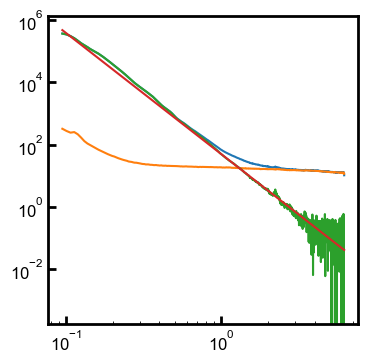

In [205]:
plt.figure(figsize=(4,4))
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_86_RT'
Exp = BM26_experiment(path)
q, I = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.loglog(q, sum(I))
plt.loglog(q, .373 * bkg)

x = q
y = sum(I) - .373 * bkg

plt.plot(x, y)
p, cov = curve_fit(power, x[(x>1.8)*(x<3.5)], y[(x>1.8)*(x<3.5)])
plt.plot(x, power(x,*p))

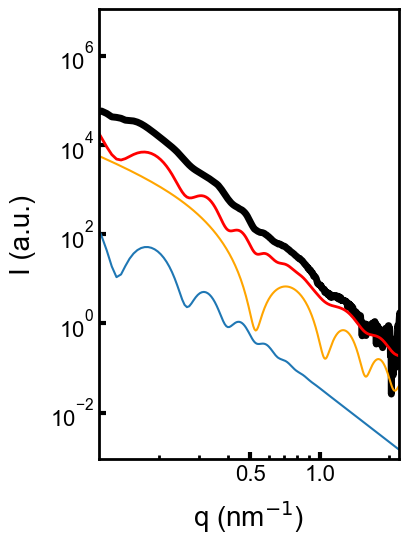

In [206]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.loglog(x, y-.85* power(x, *p), linewidth=5, color='black')

# '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
Lc = 48
I1 = polydisperse_lamellae(x, 4e3, Lc, .07, 0)
I2 = polydisperse_lamellae(x, 4e3, Lc / 2, .05, 0)
I4 = polydisperse_lamellae(x, 4e3, Lc / 4, .05, 0)

plt.plot(x, 1 * (I1 + .02 * I4), color='r', linestyle='-', linewidth=2)
plt.plot(x, I1 * 1e-2, )
plt.plot(x, I4 * 20e-3, color='orange')
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)
ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3, labelsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.5, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.xlim(.11, 2.2)
plt.ylim(.9e-3, 1.1e7)

plt.savefig(r'E:\PE Nikos 2025\figures\NG86.png', dpi=300, bbox_inches='tight', transparent=True)
I86 = y-.85* power(x, *p)

#### 96

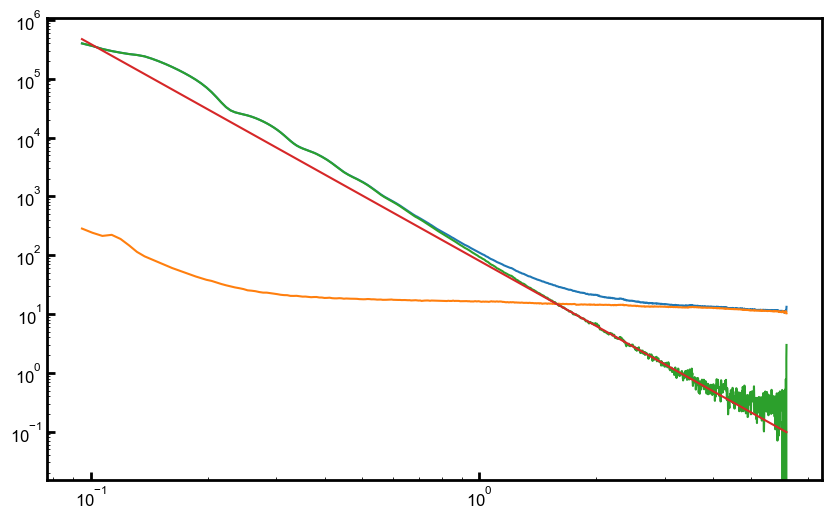

In [207]:
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_96_RT'
Exp = BM26_experiment(path)
q, I = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.loglog(q, sum(I))
Tr = .33
plt.loglog(q, Tr * bkg)

x = q
y = sum(I) - Tr * bkg

plt.plot(x, y)
p, cov = curve_fit(power, x[(x>1.8)*(x<3.5)], y[(x>1.8)*(x<3.5)])
plt.plot(x, power(x,*p))

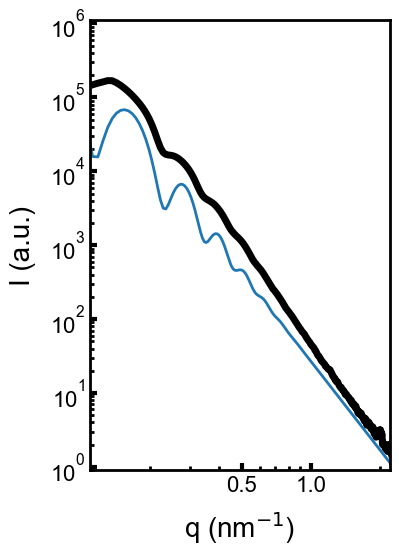

In [208]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.loglog(x, y-.6* power(x, *p), linewidth=5, color='black')

# '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
Lc = 55
I1 = polydisperse_lamellae(x, 4e3, Lc, .07, 0)

plt.plot(x, 10 * I1, linestyle='-', linewidth=2)
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)
ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3, labelsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.5, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.xlim(.11, 2.2)
plt.ylim(.9e0, 1.1e6)

plt.savefig(r'E:\PE Nikos 2025\figures\NG96.png', dpi=300, bbox_inches='tight', transparent=True)
I96 =  y-.6* power(x, *p)

#### 82B

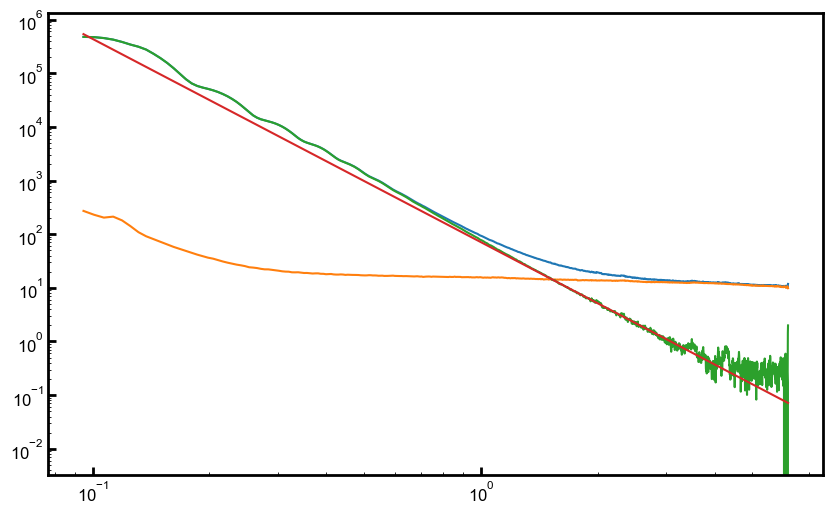

In [209]:
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_82B_RT'
Exp = BM26_experiment(path)
q, I = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.loglog(q, sum(I))
Tr = .316
plt.loglog(q, Tr * bkg)

x = q
y = sum(I) - Tr * bkg

plt.plot(x, y)
p, cov = curve_fit(power, x[(x>1.8)*(x<3.5)], y[(x>1.8)*(x<3.5)])
plt.plot(x, power(x,*p))

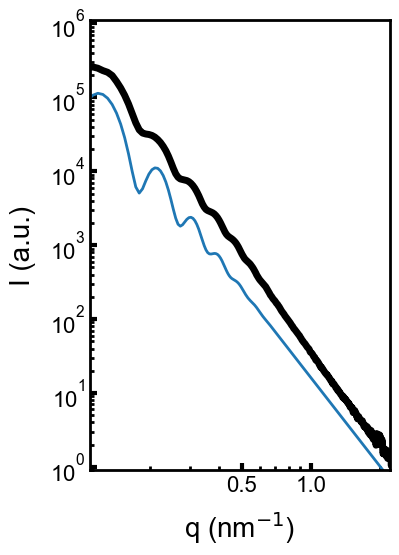

In [211]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.loglog(x, y-.6* power(x, *p), linewidth=5, color='black')

# '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
Lc = 71
I1 = polydisperse_lamellae(x, 4e3, Lc, .07, 0)

plt.plot(x, 10 * I1, linestyle='-', linewidth=2)
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)
ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3, labelsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.5, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.xlim(.11, 2.2)
plt.ylim(.9e0, 1.1e6)

plt.savefig(r'E:\PE Nikos 2025\figures\NG82B.png', dpi=300, bbox_inches='tight', transparent=True)
I82B =  y-.6* power(x, *p)

#### 101

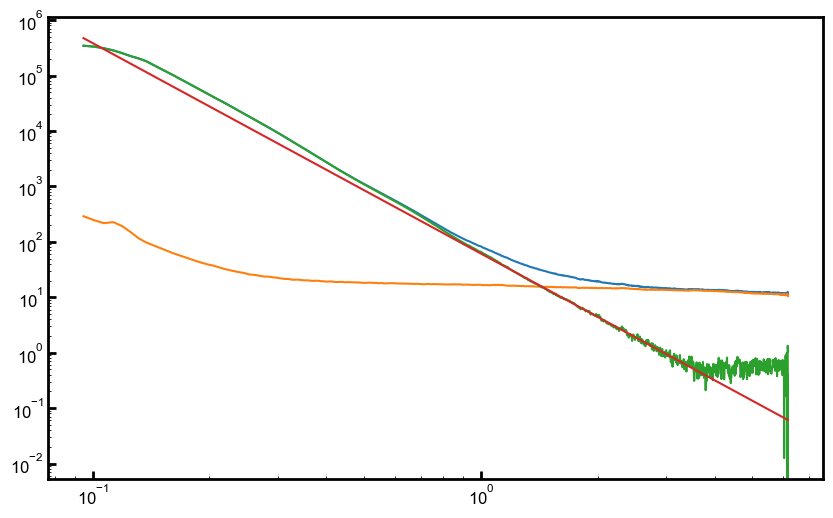

In [255]:
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_101_RT'
Exp = BM26_experiment(path)
q, I = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.loglog(q, sum(I))
Tr = .337
plt.loglog(q, Tr * bkg)

x = q
y = sum(I) - Tr * bkg

plt.plot(x, y)
p, cov = curve_fit(power, x[(x>1.8)*(x<3.5)], y[(x>1.8)*(x<3.5)])
plt.plot(x, power(x,*p))

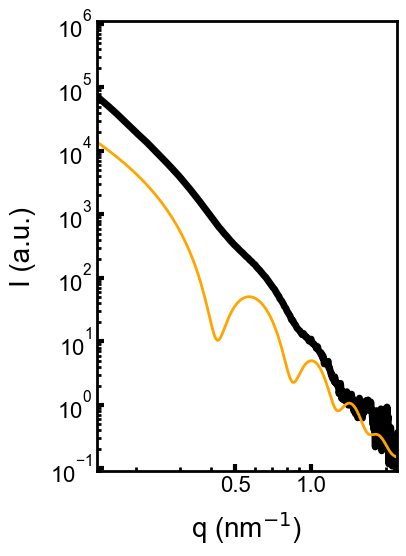

In [256]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.loglog(x, y-.9* power(x, *p), linewidth=5, color='black')

# '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
Lc = 15
I1 = polydisperse_lamellae(x, 4e2, Lc, .07, 0)

plt.plot(x, I1, linestyle='-', linewidth=2, color='orange')
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)
ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3, labelsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.5, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.xlim(.14, 2.2)
plt.ylim(.9e-1, 1.1e6)

plt.savefig(r'E:\PE Nikos 2025\figures\NG101.png', dpi=300, bbox_inches='tight', transparent=True)
I101 = y-.9* power(x, *p)

#### 97

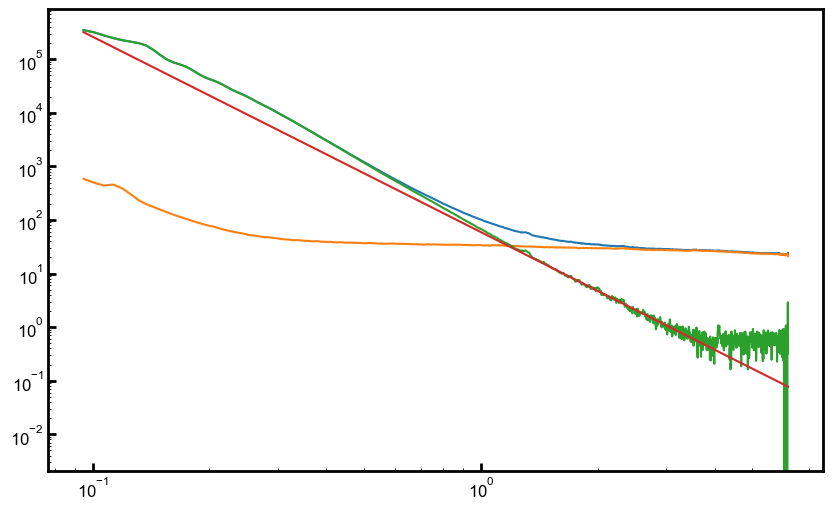

In [214]:
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_97_RT'
Exp = BM26_experiment(path)
q, I = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.loglog(q, sum(I))
Tr = .681
plt.loglog(q, Tr * bkg)

x = q
y = sum(I) - Tr * bkg

plt.plot(x, y)
p, cov = curve_fit(power, x[(x>1.8)*(x<3.5)], y[(x>1.8)*(x<3.5)])
plt.plot(x, power(x,*p))

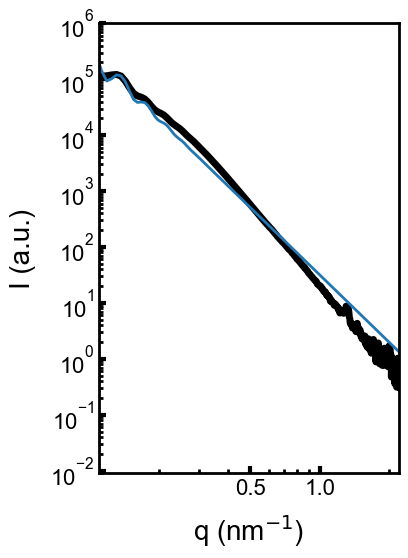

In [215]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.loglog(x, y-.8 * power(x, *p), linewidth=5, color='black')

# '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
Lc = 160
I1 = polydisperse_lamellae(x, 4e5, Lc, .07, 0)

plt.plot(x, I1, linestyle='-', linewidth=2)
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)
ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3, labelsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.5, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.xlim(.11, 2.2)
plt.ylim(.9e-2, 1e6)

plt.savefig(r'E:\PE Nikos 2025\figures\NG97.png', dpi=300, bbox_inches='tight', transparent=True)
I97 = y-.8 * power(x, *p)

#### 87

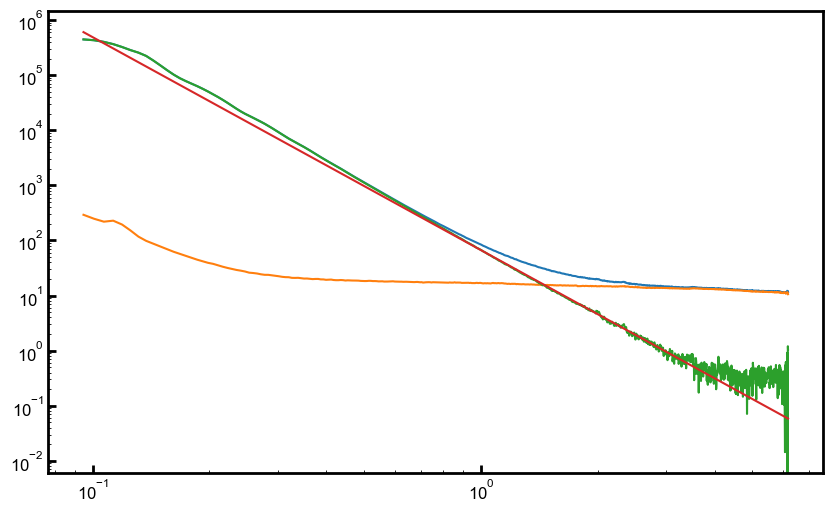

In [216]:
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_87_RT'
Exp = BM26_experiment(path)
q, I = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.loglog(q, sum(I))
Tr = .34
plt.loglog(q, Tr * bkg)

x = q
y = sum(I) - Tr * bkg

plt.plot(x, y)
p, cov = curve_fit(power, x[(x>1.8)*(x<3.5)], y[(x>1.8)*(x<3.5)])
plt.plot(x, power(x,*p))

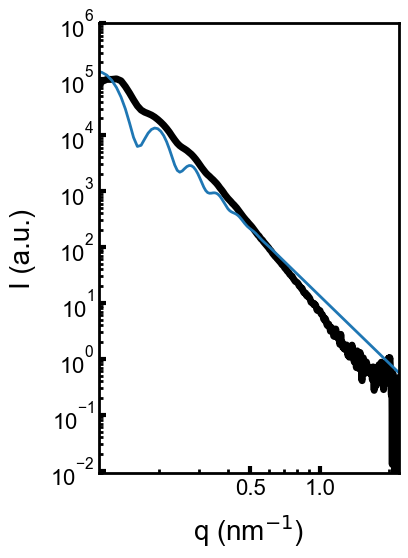

In [218]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.loglog(x, y-.9 * power(x, *p), linewidth=5, color='black')

# '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
Lc = 78
I1 = polydisperse_lamellae(x, 4e4, Lc, .07, 0)

plt.plot(x, I1, linestyle='-', linewidth=2)
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)
ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3, labelsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.5, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.xlim(.11, 2.2)
plt.ylim(.9e-2, 1e6)

plt.savefig(r'E:\PE Nikos 2025\figures\NG87.png', dpi=300, bbox_inches='tight', transparent=True)
I87 = y-.9 * power(x, *p)

#### 102

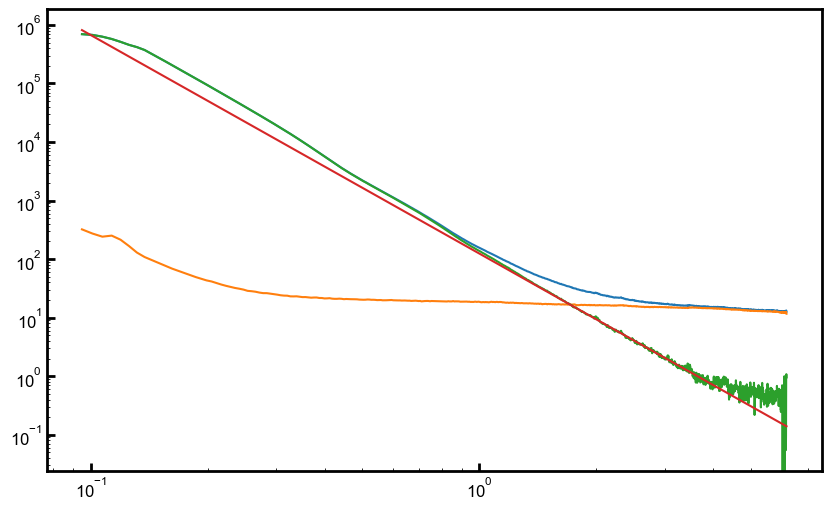

In [253]:
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_102_RT'
Exp = BM26_experiment(path)
q, I = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
plt.loglog(q, sum(I))
Tr = .375
plt.loglog(q, Tr * bkg)

x = q
y = sum(I) - Tr * bkg

plt.plot(x, y)
p, cov = curve_fit(power, x[(x>1.8)*(x<3.5)], y[(x>1.8)*(x<3.5)])
plt.plot(x, power(x,*p))

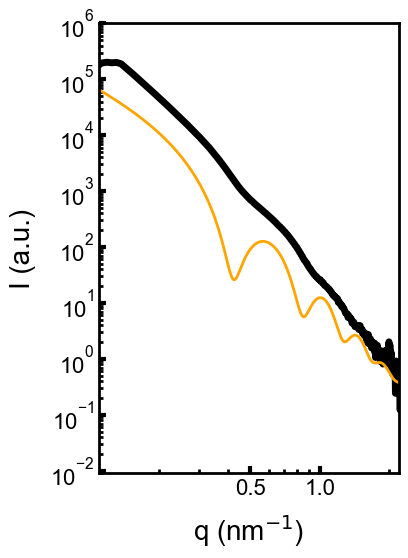

In [254]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.loglog(x, y-.9 * power(x, *p), linewidth=5, color='black')

# '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
Lc = 15
I1 = polydisperse_lamellae(x, 1e3, Lc, .07, 0)

plt.plot(x, I1, linestyle='-', linewidth=2, color='orange')
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)
ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3, labelsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.5, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.xlim(.11, 2.2)
plt.ylim(.9e-2, 1e6)

plt.savefig(r'E:\PE Nikos 2025\figures\NG102.png', dpi=300, bbox_inches='tight', transparent=True)
I102 = y-.9 * power(x, *p)

# Figure

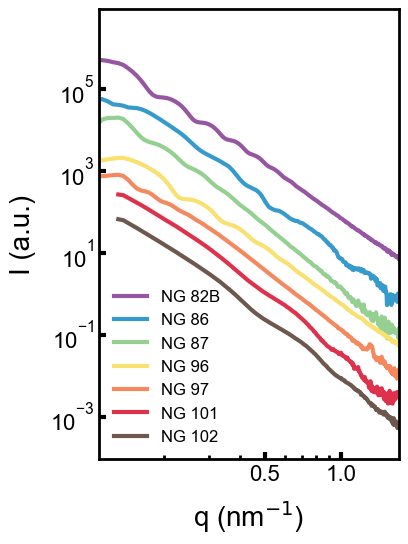

In [285]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

l=3
colors = ["#9656a2","#369acc","#95cf92","#f8e16f","#f4895f","#de324c","#6c584c"]
plt.loglog(x[I82B>0], I82B[I82B>0] * 2, linewidth=l, color=colors[0], label='NG 82B')
plt.loglog(x[I86>0], I86[I86>0] * 1, linewidth=l, color=colors[1], label='NG 86')
plt.loglog(x[I87>0], I87[I87>0] / 5, linewidth=l, color=colors[2], label='NG 87')
plt.loglog(x[I96>0], I96[I96>0] / 80, linewidth=l, color=colors[3], label='NG 96' )
plt.loglog(x[I97>0], I97[I97>0] / 150, linewidth=l, color=colors[4], label='NG 97')

plt.loglog(x[(I101>0)*(x>.13)], I101[(I101>0)*(x>.13)] / 300, linewidth=l, color=colors[5], label='NG 101')
plt.loglog(x[(I102>0)*(x>.13)], I102[(I102>0)*(x>.13)] / 3000, linewidth=l, color=colors[6], label='NG 102') 

# '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
Lc = 15

ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)
ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3, labelsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.5, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.xlim(.11, 1.7)
plt.ylim(.9e-4, 9e6)
ax.legend(fontsize=12, frameon=False, fancybox=False, shadow=False)
plt.savefig(r'E:\PE Nikos 2025\figures\all_1.png', dpi=300, bbox_inches='tight', transparent=True)


In [322]:
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_82B_firstheat_160C_and_back_bis'
Exp = BM26_experiment(path)

q, I_heat = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

In [323]:
path = r'E:\PE Nikos 2025\SC 5732\PE_samples\PE_samples_NG_86_redissolv_RT'
Exp = BM26_experiment(path)

q, I_red = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

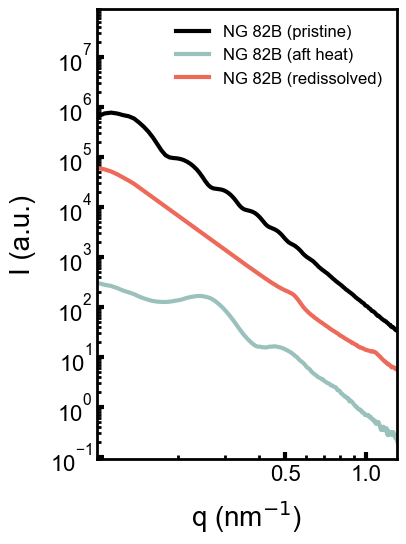

In [340]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

plt.loglog(x[I82B>0], 3 * I82B[I82B>0], linewidth=l, label='NG 82B (pristine)', color='black')
plt.plot(q, .5 * (I_heat[-1]-.03 * bkg), color='#9bc1bc', linewidth=l, label='NG 82B (aft heat)')
plt.plot(q,  (I_red[-1]-.034 * bkg), color='#ed6a5a', linewidth=l, label='NG 82B (redissolved)')

ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)
ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3, labelsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([0.5, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.xlim(.1, 1.3)
plt.ylim(.9e-1, 9e7)
ax.legend(fontsize=12, frameon=False, fancybox=False, shadow=False)

plt.savefig(r'E:\PE Nikos 2025\figures\heat_82B.png', dpi=300, bbox_inches='tight', transparent=True)
